# ROMS-DART Data Assimilation Experiment

This notebook goes over the EnKF output from DART and diagnoses the results. 
The converter itself should be run from the terminal. This notebook focuses on reading, summarizing, and visualizing the assimilation results.

## Objectives

In this notebook you will learn how to:

- Read a DART `obs_seq.final` file
- Summarize possible, used, and rejected observations
- Inspect DART QC flags
- Visualize geographic patterns of rejected observations
- Examine profile diagnostics such as RMSE, bias, and spread
- Assess ensemble reliability using rank histograms

## 1. Import Python libraries

In [ ]:
import pydartdiags.obs_sequence.obs_sequence as obsq

import os
import cmocean
import numpy             as np
import pandas            as pd
import xarray            as xr
import plotly.io         as pio
import cartopy.crs       as ccrs
import plotly.express    as px
import cartopy.feature   as cfeature
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates

from pathlib              import Path
from IPython.display      import Markdown, display
from pydartdiags.stats    import stats
from pydartdiags.matplots import matplots as mp

## 2. Define paths

In [ ]:
# Path to DART repo (directory) 
basedir = Path(f"/glade/derecho/scratch/{os.environ['USER']}/inacawo/DART_training/models/ROMS_rutgers/work")
diagdir = basedir / 'filter_output' 

# Path to the obs_seq and obs_diag_output.nc files
obs_seq_file  = diagdir / 'obs_seq.final' 
obs_diag_file = diagdir / 'obs_diag_output.nc' 

print(f"obs_seq file: {obs_seq_file}")
print(f"obs_diag file: {obs_diag_file}")

# Make sure the obs_Seq file exists
assert obs_seq_file.exists(), 'obs_seq file not found'
assert obs_diag_file.exists(), 'obs_diag file not found'

# Roms restart template 
roms_rst = basedir / 'roms_template.nc'

## 3. Read and preview the obs_seq.final file

In [ ]:
obs = obsq.ObsSequence(obs_seq_file)

df = obs.df.copy()
df["error_sd"] = np.sqrt(df["obs_err_var"])

qc_col = "QC"

display(obs.df.head())

display(Markdown("### obs_seq.final summary"))

print(f"Total observations : {len(df):,}")
print(f"Observation types  : {df['type'].nunique()}")
print(f"Time range         : {df['time'].min()} to {df['time'].max()}")
print(f"Longitude range    : {df['longitude'].min():.2f}° to {df['longitude'].max():.2f}°")
print(f"Latitude range     : {df['latitude'].min():.2f}° to {df['latitude'].max():.2f}°")

display(Markdown("### Observation copies"))
display(pd.DataFrame({"Copy name": obs.copie_names}))

display(Markdown("### QC copies"))
display(pd.DataFrame({"QC copy name": obs.qc_copie_names}))

In [ ]:
# Possible vs Used observations
display(Markdown("""
### Possible versus Used Observations

The table below summarizes how many observations of each type were available to the DART filter (*possible*) and how many were ultimately assimilated (*used*).

Not all observations that enter the filter are necessarily assimilated. DART assigns a QC flag to every observation, 
indicating whether it was successfully assimilated or rejected. Rejection can occur for a variety of reasons, including:

- Failure of the prior or posterior forward operator
- Observation type disabled through namelist settings
- Incoming observation quality control checks
- Outlier threshold tests
- Vertical coordinate conversion failures
- Other filter-specific diagnostics

The *rejected* count is computed as the difference between the number of possible and used observations. 
"""))

pvu = obs.possible_vs_used().copy()

pvu["rejected"]     = pvu["possible"] - pvu["used"]
pvu["rejected (%)"] = 100 * pvu["rejected"] / pvu["possible"]

display(pvu.style
           .format({"rejected (%)": "{:.1f}"})
           .hide(axis="index"))

In [ ]:
# Plot the observations on a map
pio.renderers.default = "iframe"

qc_meanings = {
    0: "assimilated",
    1: "evaluated only",
    2: "posterior FO failed after assimilation",
    3: "evaluated only, posterior FO failed",
    4: "prior forward operator failed",
    5: "obs type not listed in namelist",
    6: "incoming obs QC too large",
    7: "failed outlier threshold test",
}

df = obs.df.copy()

df["QC_flag"] = df["DART_quality_control"].astype(int)
df["QC_label"] = df["QC_flag"].map(
    lambda q: f"QC={q}: {qc_meanings.get(q, 'reserved/future use')}"
)

qc_colors = {
    "QC=0: assimilated"                           : "#1f77b4",
    "QC=1: evaluated only"                        : "#9467bd",
    "QC=2: posterior FO failed after assimilation": "#2ca02c",
    "QC=3: evaluated only, posterior FO failed"   : "#8c564b",
    "QC=4: prior forward operator failed"         : "#ff7f0e",
    "QC=5: obs type not listed in namelist"       : "#d62728",
    "QC=6: incoming obs QC too large"             : "#e377c2",
    "QC=7: failed outlier threshold test"         : "#bcbd22",
}

fig = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    color="QC_label",
    color_discrete_map=qc_colors,
    hover_data={
        "QC_flag": True,
        "type": True,
        "observation": True,
        "obs_num": True,
    }
)

fig.update_layout(
    width=950,
    height=450,
    margin=dict(l=0, r=0, t=40, b=0),
    legend_title_text="DART QC flag",
)

fig.update_geos(
    lonaxis_range=[90, 145],
    lataxis_range=[-15, 15],
    showcountries=True,
    showcoastlines=True,
    showland=True,
    landcolor="whitesmoke",
    showocean=True,
    oceancolor="aliceblue",
)

display(fig)

display(Markdown("""
### Geographic Distribution of DART QC Flags

This map shows where different DART QC outcomes occur across the ROMS domain. Each point is colored by its final DART quality-control flag.

| QC flag | Meaning |
|---:|---|
| 0 | Observation assimilated |
| 1 | Observation evaluated only because of namelist settings |
| 2 | Assimilated, but posterior forward operator failed |
| 3 | Evaluated only, but posterior forward operator failed |
| 4 | Prior forward operator failed |
| 5 | Observation type not listed in the namelist |
| 6 | Rejected because incoming observation QC was too large |
| 7 | Rejected because of a failed outlier threshold test |

With this, we can know whether rejected observations are clustered geographically or associated with specific platforms or regions.
"""))

## 4. O-B & O-A Maps 


### Satellite O-B and O-A Diagnostics

The maps below compare satellite observations with the model estimate in observation space.

**O-B** is observation-minus-background, computed using the prior ensemble mean.  
**O-A** is observation-minus-analysis, computed using the posterior ensemble mean.

If the assimilation is working as expected, the O-A differences should generally be smaller than the O-B differences, 
indicating that the analysis moved the model closer to the observations.


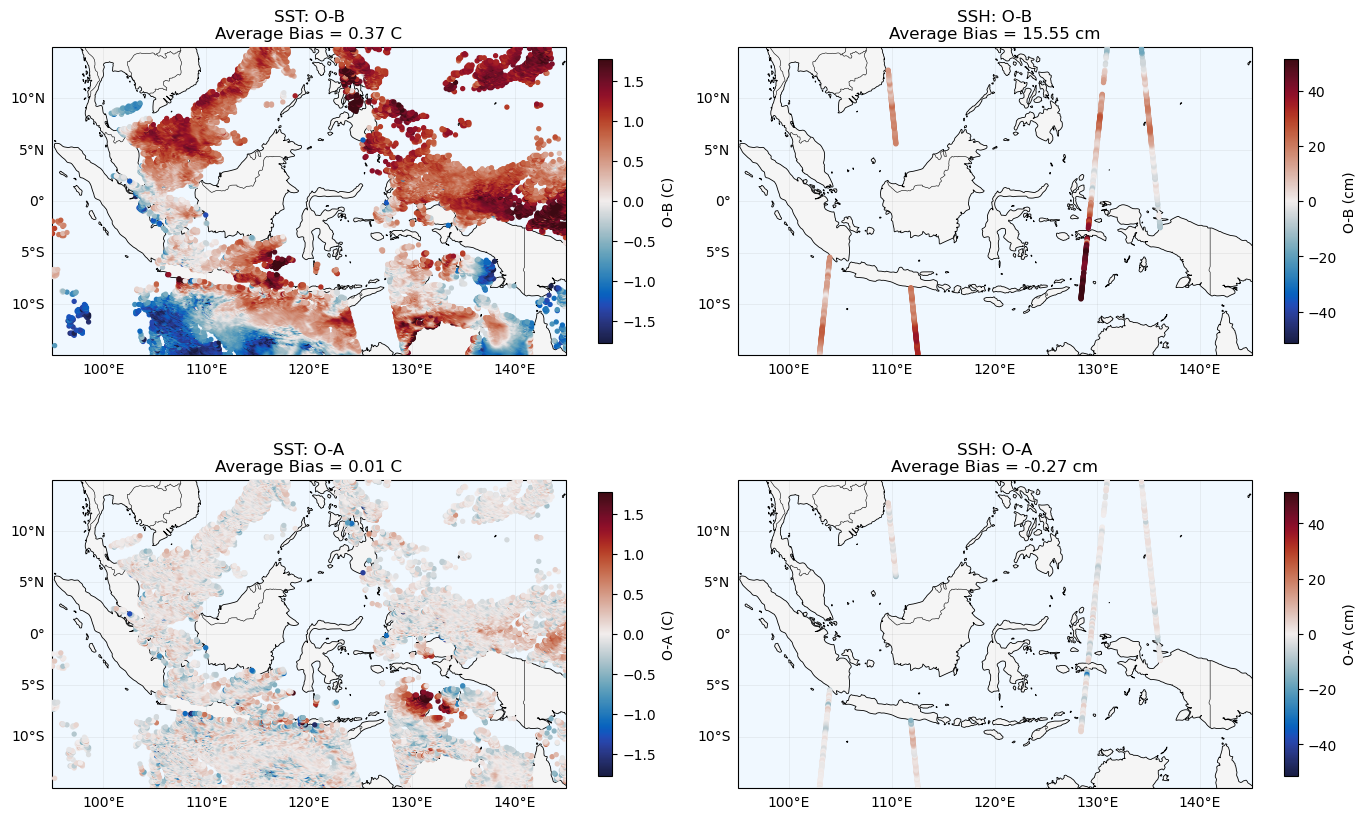

In [174]:
display(Markdown("""
### Satellite O-B and O-A Diagnostics

The maps below compare satellite observations with the model estimate in observation space.

**O-B** is observation-minus-background, computed using the prior ensemble mean.  
**O-A** is observation-minus-analysis, computed using the posterior ensemble mean.

If the assimilation is working as expected, the O-A differences should generally be smaller than the O-B differences, 
indicating that the analysis moved the model closer to the observations.
"""))

df["omb"] = df["observation"] - df["prior_ensemble_mean"]
df["oma"] = df["observation"] - df["posterior_ensemble_mean"]

plot_specs = [
    ("SATELLITE_BLENDED_SST", "SST", "C" , 1.0),
    ("SATELLITE_SSH"        , "SSH", "cm", 100.0),
]

diag_specs = [
    ("omb", "O-B"),
    ("oma", "O-A"),
]

proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9),
    subplot_kw={"projection": proj},
)

lims = {}
for obs_type, _, _, scale in plot_specs:
    this_obs = df[df["type"] == obs_type]
    lims[obs_type] = np.nanpercentile(np.abs(this_obs["omb"] * scale), 98)

for i, (diag, diag_title) in enumerate(diag_specs):
    for j, (obs_type, obs_title, units, scale) in enumerate(plot_specs):

        ax = axes[i, j]
        
        this_obs = df[df["type"] == obs_type].copy()
        values   = this_obs[diag] * scale

        if obs_type == "SATELLITE_BLENDED_SST":
            valid = np.abs(values) < 10.0
        else:
            valid = np.isfinite(values)
        
        plot_values = values[valid]
        plot_lon = this_obs["longitude"].to_numpy()[valid]
        plot_lat = this_obs["latitude"].to_numpy()[valid]

        ax.set_facecolor("aliceblue")
        ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, zorder=2)

        lim = lims[obs_type]
        
        mean_resid = np.nanmean(plot_values)
        
        sc = ax.scatter(plot_lon,plot_lat,
            c=plot_values,
            cmap=cmocean.cm.balance,
            vmin=-lim,
            vmax=lim,
            s=8,
            transform=proj,
            zorder=3,
        )

        plt.colorbar(sc, ax=ax, label=f"{diag_title} ({units})", shrink=0.65)

        ax.set_extent([95, 145, -15, 15], crs=proj)

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.15)
        gl.top_labels = False
        gl.right_labels = False

        ax.set_title(f"{obs_title}: {diag_title}\n"
                     f"Average Bias = {mean_resid:.2f} {units}", fontsize=12)

# fig.suptitle("Satellite Observation-minus-Model Diagnostics", fontsize=17)
plt.tight_layout()
plt.show()

## 5. Ensemble Statistics: RMSE, BIAS, TOTAL SPREAD


The following profile diagnostics summarize observation-space error statistics as a function of depth. 
RMSE, bias, and total spread help indicate whether the ensemble is accurate, biased, or under/overdispersive.

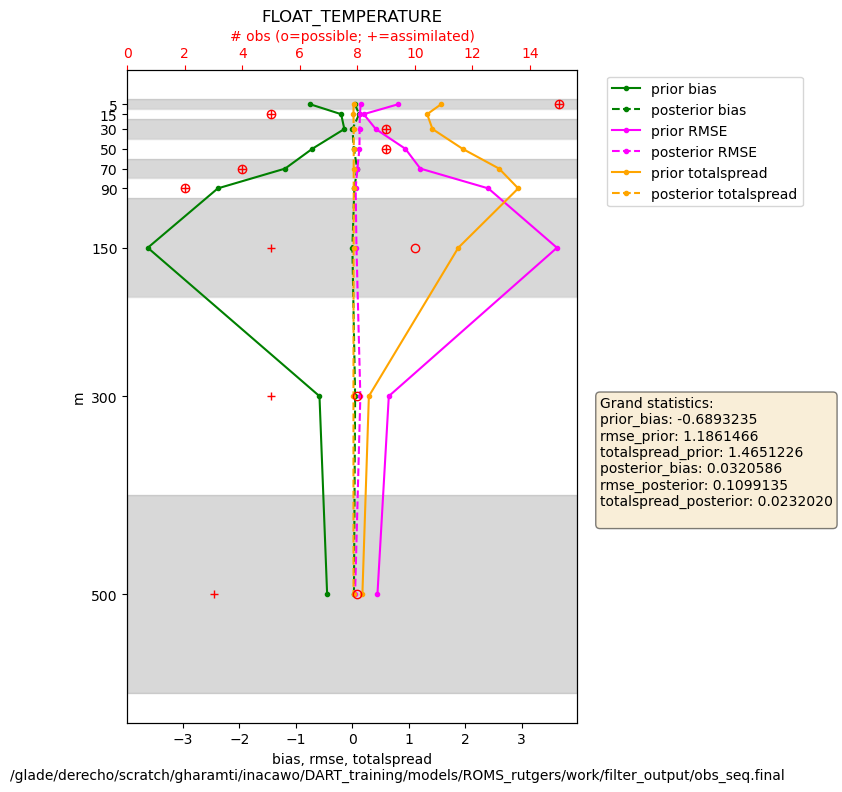


These diagnostics are computed in observation space and summarize how the ensemble compares with observations as a function of depth.


In [171]:
obs_type = 'FLOAT_TEMPERATURE' 
levels   = [0, 10, 20, 40, 60, 80, 100, 200, 400, 600]

display(Markdown("""
The following profile diagnostics summarize observation-space error statistics as a function of depth. 
RMSE, bias, and total spread help indicate whether the ensemble is accurate, biased, or under/overdispersive."""))

fig = mp.plot_profile(obs, levels, obs_type, bias=True, rmse=True, totalspread=True, depth=True)

display(Markdown("""
These diagnostics are computed in observation space and summarize how the ensemble compares with observations as a function of depth.
"""))

## 6. Ensemble Reliability


Rank histograms assess ensemble reliability in observation space. 
A flat histogram indicates a statistically consistent ensemble; 
U-shaped histograms suggest underdispersion; 
dome-shaped histograms suggest overdispersion; skewness suggests bias.

In practice, a perfectly flat rank histogram is rarely achieved. 
The primary goal is to identify major departures from flatness that indicate underdispersion, overdispersion, or systematic bias.

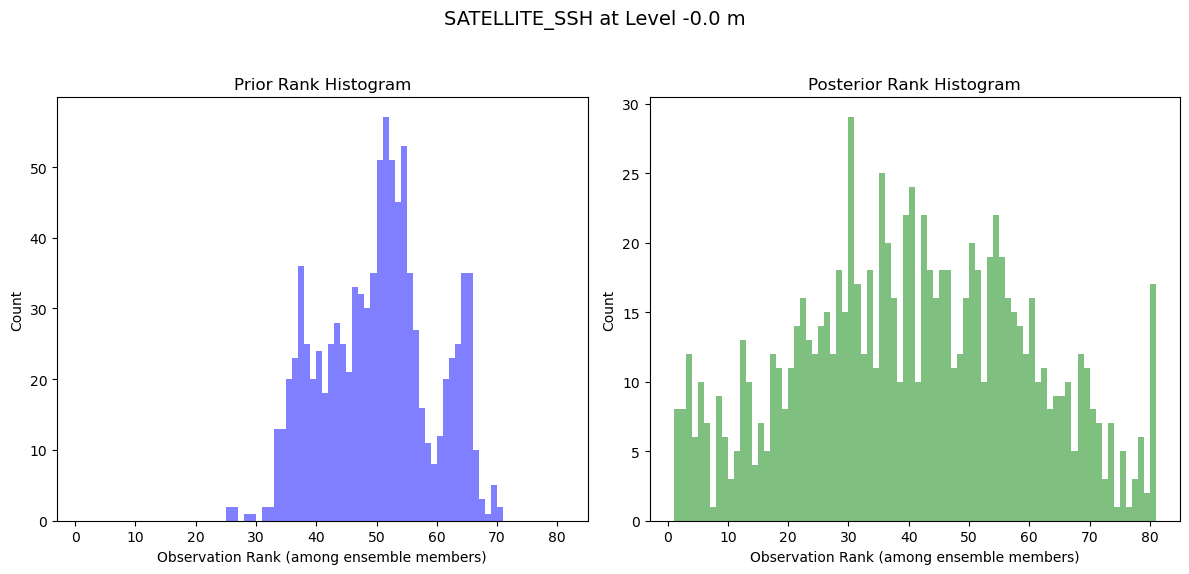

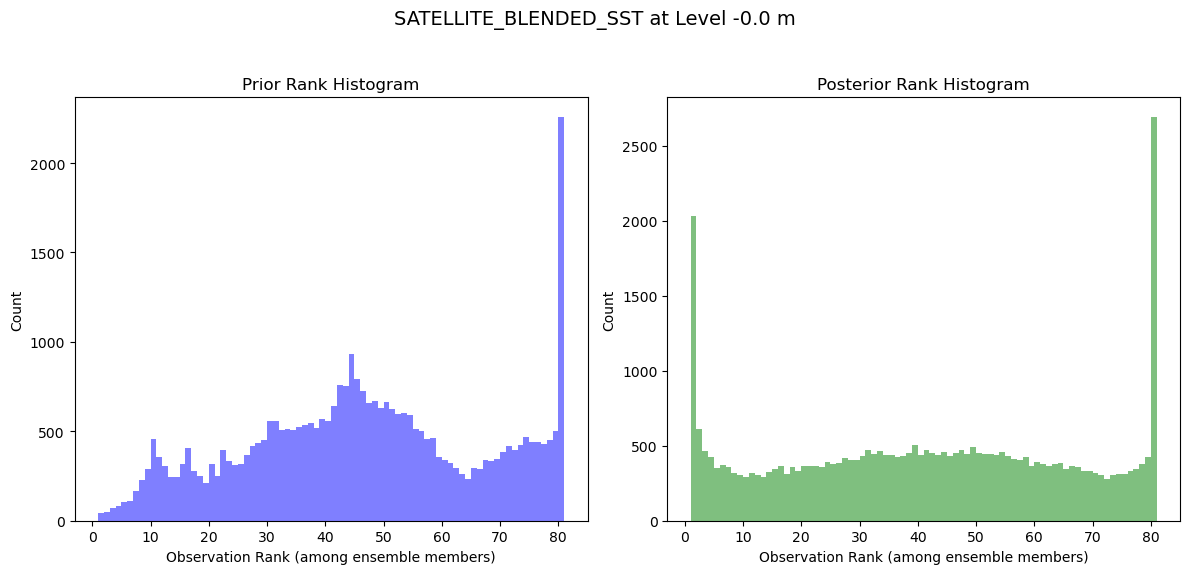

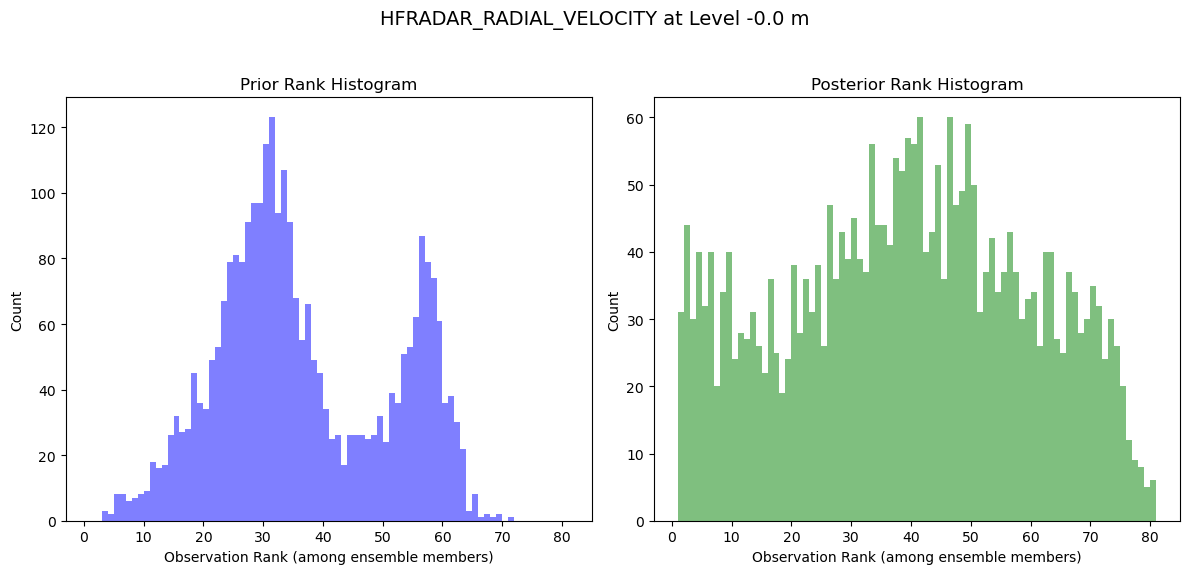

In [173]:
# Rank Histograms
display(Markdown("""
Rank histograms assess ensemble reliability in observation space. 
A flat histogram indicates a statistically consistent ensemble; 
U-shaped histograms suggest underdispersion; 
dome-shaped histograms suggest overdispersion; skewness suggests bias.

In practice, a perfectly flat rank histogram is rarely achieved. 
The primary goal is to identify major departures from flatness that indicate underdispersion, overdispersion, or systematic bias."""))

ens_size  = 80
obs_types = ['SATELLITE_SSH', 'SATELLITE_BLENDED_SST', 'HFRADAR_RADIAL_VELOCITY']

levels = [0.0, 0.0]

for obs_type in obs_types:
    fig = mp.plot_rank_histogram(obs, obs_type, ens_size, levels)

## Key Takeaways

- DART successfully processed close to 45,000 observations spanning 10 different observation types, including satellite SST, satellite SSH, HF radar currents, profiling floats, and surface drifters.
- The vast majority of the observations were successfully assimilated (QC = 0), demonstrating that the ROMS-DART system was able to ingest and process a diverse observational network.
- Most rejected observations were associated with either prior forward operator failures (QC = 4) or failed outlier threshold tests (QC = 7). The geographic map helps identify where these rejections occurred (e.g., near the coast).
- Satellite SST observations provide the largest spatial coverage across the Indonesian domain and dominate the observing network in terms of observation count.
- Satellite SSH observations are concentrated along a limited number of satellite ground tracks but provide valuable information on the large-scale sea surface height structure.
- Observation-minus-background (O-B) diagnostics reveal coherent spatial patterns, indicating regions where the model prior differs systematically from the observations.
- Observation-minus-analysis (O-A) residuals are substantially smaller in magnitude than the corresponding O-B residuals, demonstrating that the assimilation successfully moves the model state closer to the observations.
- The reduction from O-B to O-A residuals indicates that the assimilation successfully incorporated observational information into the analysis.
- Profile diagnostics and rank histograms provide complementary perspectives on system performance, quantifying both forecast skill and ensemble reliability.
- Together, these diagnostics demonstrate that the ROMS-DART workflow is functioning correctly and provide a foundation for more detailed tuning and performance evaluation experiments.